# 07A – SHAP Global Explainability (Enterprise)

## Business Objective
Understand **which financial features most influence bankruptcy predictions** at a global level using SHAP (SHapley Additive exPlanations). This notebook helps validate the model, improve transparency, and provide business stakeholders with interpretable insights.


In [1]:
import pandas as pd
import numpy as np
import shap
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

# Load trained production model
model = joblib.load("../models/production_bankruptcy_model.joblib")

# Load data
df = pd.read_csv("../data/datasets/american_bankruptcy.csv")
df["target"] = df["status_label"].map({"alive":0,"failed":1})

drop_cols=["status_label","target"]
if "company_name" in df.columns:
    drop_cols.append("company_name")

X=df.drop(columns=drop_cols)
y=df["target"]

_, X_test, _, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

display(X_test.head())
print("Test shape:", X_test.shape)


,year,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18
55080,2018,65.666,125.434,6.048,16.848,46.526,5.923,13.840,17.5050,199.633,141.524,64.235,10.800,74.199,37.261,-22.654,199.633,102.075,182.785
37401,2015,705.563,890.266,27.626,-141.832,11.864,-179.817,193.643,4384.4824,1267.118,894.772,0.049,-169.458,376.852,334.202,-608.834,1267.118,386.724,1408.950
76050,2012,5.252,5.143,0.293,-4.559,0.000,-4.845,0.080,45.0176,0.584,6.782,0.000,-4.852,-4.559,0.584,-10.950,0.584,0.584,5.143
76056,2018,179.564,141.661,9.009,-120.468,0.000,-203.540,4.359,293.4720,21.193,624.087,223.136,-129.477,-120.468,61.621,-367.735,21.193,416.587,141.661
76705,2013,525.377,1762.479,96.032,206.859,81.278,-20.275,255.674,438.1222,2102.019,1182.993,464.086,110.827,339.540,431.296,-245.240,2102.019,1046.124,1895.160


Test shape: (15737, 19)


## Create SHAP Explainer

In [2]:
# Sample to reduce computation time
X_sample = X_test.sample(min(200, len(X_test)), random_state=42)

# TreeExplainer is used instead of the generic permutation Explainer: it's
# exact (not approximated) and far faster for tree-based models like this one.
explainer = shap.TreeExplainer(model)
shap_values = explainer(X_sample)
# Binary classifier -> shape (n_samples, n_features, n_classes); keep the
# positive ("failed") class for the plots below.
if shap_values.values.ndim == 3:
    shap_values = shap_values[:, :, 1]

print("SHAP values computed successfully.")


SHAP values computed successfully.


## SHAP Summary (Beeswarm)

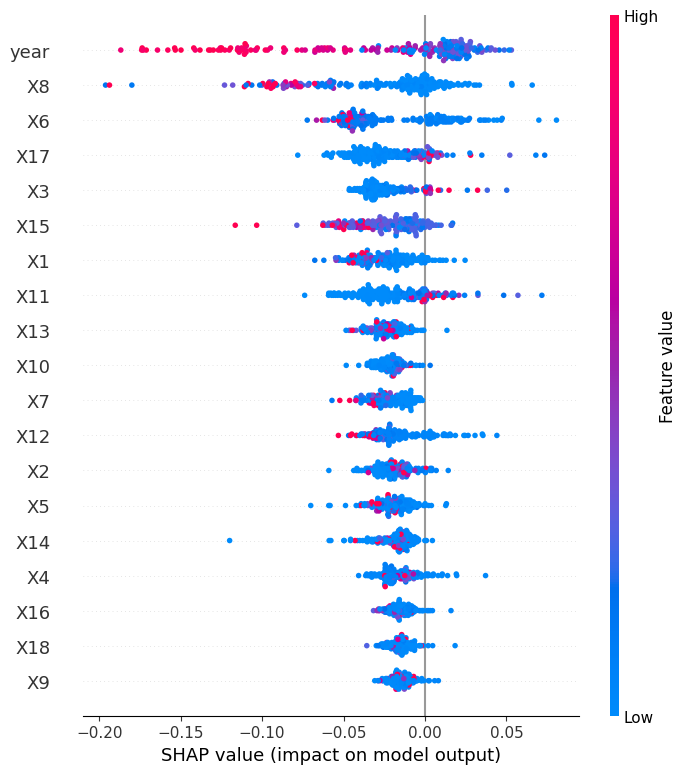

In [3]:
shap.plots.beeswarm(shap_values, max_display=20)
plt.show()


## SHAP Bar Plot

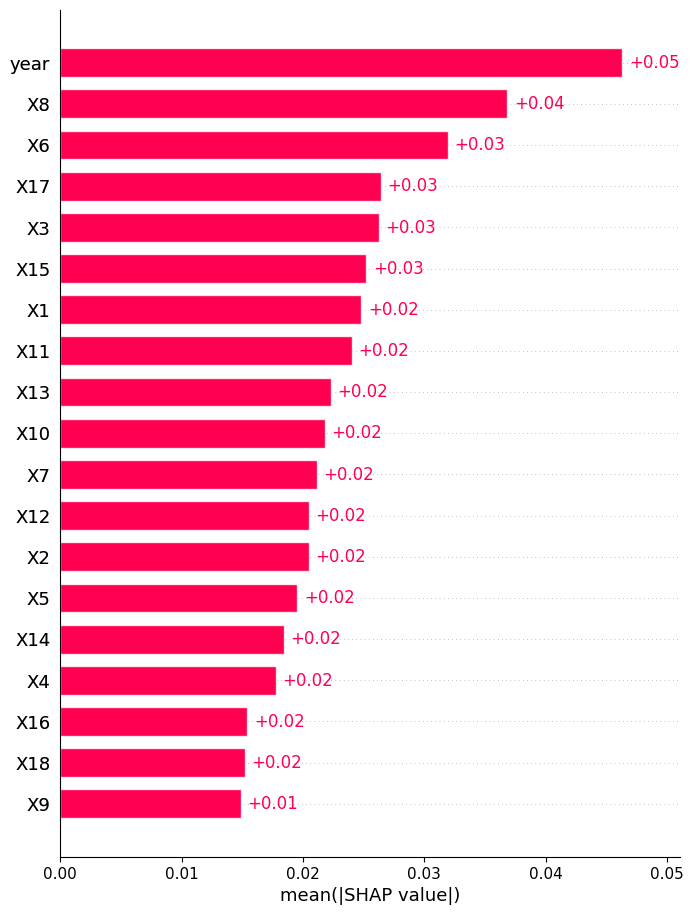

In [4]:
shap.plots.bar(shap_values, max_display=20)
plt.show()


## Global Feature Importance Table

In [5]:
importance = pd.DataFrame({
    "Feature": X_sample.columns,
    "MeanAbsSHAP": np.abs(shap_values.values).mean(axis=0)
}).sort_values("MeanAbsSHAP", ascending=False)

display(importance)
importance.to_csv("shap_global_feature_importance.csv", index=False)


,Feature,MeanAbsSHAP
0,year,0.046311
8,X8,0.036837
6,X6,0.031950
17,X17,0.026435
3,X3,0.026263
15,X15,0.025208
1,X1,0.024810
11,X11,0.024012
13,X13,0.022310
10,X10,0.021805


## Top 10 Bankruptcy Drivers

,Feature,MeanAbsSHAP
0,year,0.046311
8,X8,0.036837
6,X6,0.031950
17,X17,0.026435
3,X3,0.026263
15,X15,0.025208
1,X1,0.024810
11,X11,0.024012
13,X13,0.022310
10,X10,0.021805


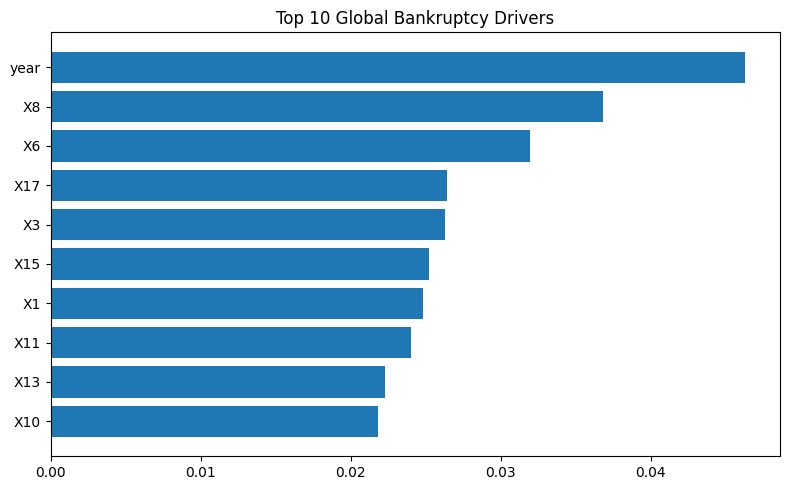

In [6]:
display(importance.head(10))

plt.figure(figsize=(8,5))
plt.barh(
    importance.head(10)["Feature"][::-1],
    importance.head(10)["MeanAbsSHAP"][::-1]
)
plt.title("Top 10 Global Bankruptcy Drivers")
plt.tight_layout()
plt.show()


## Business Interpretation

In [7]:
top = importance.head(5)

print("Top risk-driving features:")
for _, row in top.iterrows():
    print(f"- {row['Feature']} (Mean |SHAP| = {row['MeanAbsSHAP']:.4f})")

print("\nInterpretation:")
print("- Higher SHAP magnitude indicates greater influence on bankruptcy prediction.")
print("- Review these variables with finance stakeholders for actionable risk monitoring.")


Top risk-driving features:
- year (Mean |SHAP| = 0.0463)
- X8 (Mean |SHAP| = 0.0368)
- X6 (Mean |SHAP| = 0.0319)
- X17 (Mean |SHAP| = 0.0264)
- X3 (Mean |SHAP| = 0.0263)

Interpretation:
- Higher SHAP magnitude indicates greater influence on bankruptcy prediction.
- Review these variables with finance stakeholders for actionable risk monitoring.


## Executive Summary

In [8]:
print("✔ Global explainability completed.")
print("✔ SHAP feature rankings exported to 'shap_global_feature_importance.csv'.")
print("✔ Proceed to Notebook 07B for local explanations of individual companies.")


✔ Global explainability completed.
✔ SHAP feature rankings exported to 'shap_global_feature_importance.csv'.
✔ Proceed to Notebook 07B for local explanations of individual companies.
